## Maps with pandas: GeoPandas

You can read in Shapefiles into python using GeoPandas which works a lot like our beloved Pandas.

In [1]:
# !pip install geopandas folium matplotlib

import geopandas as gpd
import matplotlib.pyplot as plt
import folium

# ─────────────────────────────────────────────────────────────
# 1. Static Map: United States
# ─────────────────────────────────────────────────────────────

# Load the built-in world map and filter to the U.S.
# Link: https://www.naturalearthdata.com/downloads/110m-cultural-vectors/110m-admin-0-countries
# Hit Download countries that downloads a zip file containing the shapefile in .shp format.
# Unzip and paste the path of it into gpd.read_file as below. Note that the line below uses the path
# on my own computer. You need to change it to your own path.
world = gpd.read_file("/Users/bilene/Downloads/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")

In [2]:
world

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,Admin-0 country,1,5,Republic of Serbia,SRB,0,2,Sovereign country,1,Republic of Serbia,...,None,None,None,None,None,None,None,None,None,"POLYGON ((18.82982 45.90887, 18.82984 45.90888..."
173,Admin-0 country,1,6,Montenegro,MNE,0,2,Sovereign country,1,Montenegro,...,None,None,None,None,None,None,None,None,None,"POLYGON ((20.0707 42.58863, 19.80161 42.50009,..."
174,Admin-0 country,1,6,Kosovo,KOS,0,2,Disputed,1,Kosovo,...,Admin-0 country,Unrecognized,Admin-0 country,Unrecognized,Admin-0 country,Admin-0 country,Admin-0 country,Admin-0 country,Unrecognized,"POLYGON ((20.59025 41.85541, 20.52295 42.21787..."
175,Admin-0 country,1,5,Trinidad and Tobago,TTO,0,2,Sovereign country,1,Trinidad and Tobago,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-61.68 10.76, -61.105 10.89, -60.895..."


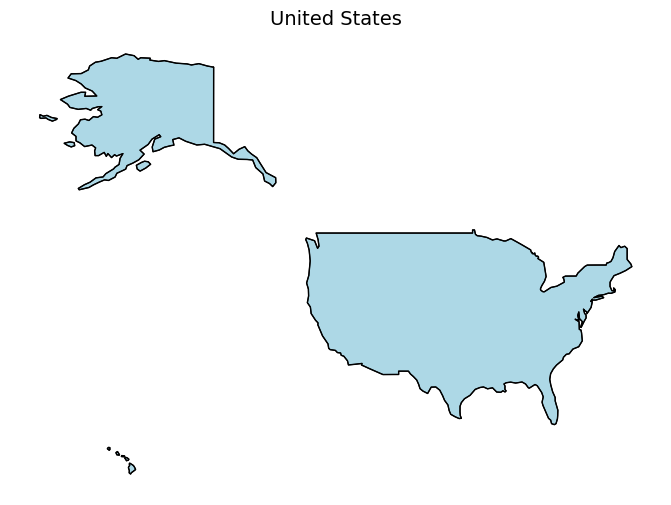

In [4]:
usa = world[world.NAME == "United States of America"]

# Plot using Matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
usa.boundary.plot(ax=ax, color="black", linewidth=0.8)
usa.plot(ax=ax, color="lightblue", edgecolor="black")
ax.set_title("United States", fontsize=14)
ax.set_axis_off()
plt.show()

In [5]:
# ─────────────────────────────────────────────────────────────
# 2. Load Shapefile of U.S. States
# ─────────────────────────────────────────────────────────────

# Replace with your path to the shapefile (downloaded separately)
# Example: https://www.census.gov/geographies/mapping-files/time-series/geo/carto-boundary-file.html
shp_path = "/Users/bilene/Downloads/us-states/us-states.shp"
states = gpd.read_file(shp_path)
print(states.head())


# ─────────────────────────────────────────────────────────────
# 3. Interactive Map: Base Map
# ─────────────────────────────────────────────────────────────

# Create a Folium map centered on the continental U.S.
m = folium.Map(location=[37.8, -96], zoom_start=4, tiles="OpenStreetMap")

# Add GeoJSON layer with simple styling
folium.GeoJson(
    states,
    name="US States",
    tooltip=folium.features.GeoJsonTooltip(fields=["NAME"]),
    style_function=lambda x: {
        "fillColor": "#a6cee3",
        "color": "black",
        "weight": 0.5,
        "fillOpacity": 0.7
    }
).add_to(m)

m  # Display interactive map


  GEOID        NAME  population   age  \
0    01     Alabama   4903185.0  39.4   
1    02      Alaska    731545.0  35.0   
2    04     Arizona   7278717.0  38.3   
3    05    Arkansas   3017804.0  38.8   
4    06  California  39512223.0  37.0   

                                            geometry  
0  POLYGON ((-88.46866 31.89386, -88.46866 31.933...  
1  MULTIPOLYGON (((179.48132 51.9753, 179.58286 5...  
2  POLYGON ((-114.79968 32.59362, -114.80939 32.6...  
3  POLYGON ((-94.61792 36.49941, -94.3612 36.4996...  
4  MULTIPOLYGON (((-118.59397 33.4672, -118.48478...  


In [6]:
import folium
import geopandas as gpd

# Load shapefile 
# This file comes from us-states posted on our course webpage on github under notes>week6
# Again, after unzipping, replace with your path
shp_path = "/Users/bilene/Downloads/us-states/us-states.shp"
states = gpd.read_file(shp_path)

# Example population data (if missing)
if "population" not in states.columns:
    import numpy as np
    np.random.seed(0)
    states["population"] = np.random.randint(0.5, 40, len(states)) * 1_000_000

# Create map
m_pop = folium.Map(location=[37.8, -96], zoom_start=4, tiles="CartoDB positron")

# Choropleth layer (color shading)
choropleth = folium.Choropleth(
    geo_data=states,
    data=states,
    columns=["NAME", "population"],
    key_on="feature.properties.NAME",
    fill_color="Blues",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Population",
    highlight=True
).add_to(m_pop)

# GeoJson layer with tooltip (hover info)
folium.GeoJson(
    states,
    name="Hover Info",
    style_function=lambda x: {
        "fillColor": "transparent",
        "color": "black",
        "weight": 0.2,
        "fillOpacity": 0,
    },
    highlight_function=lambda x: {
        "weight": 2,
        "color": "yellow",
        "fillOpacity": 0.3,
    },
    tooltip=folium.features.GeoJsonTooltip(
        fields=["NAME", "population"],
        aliases=["State:", "Population:"],
        localize=True,
        sticky=True
    ),
).add_to(m_pop)

m_pop.save("us_map.html")

m_pop


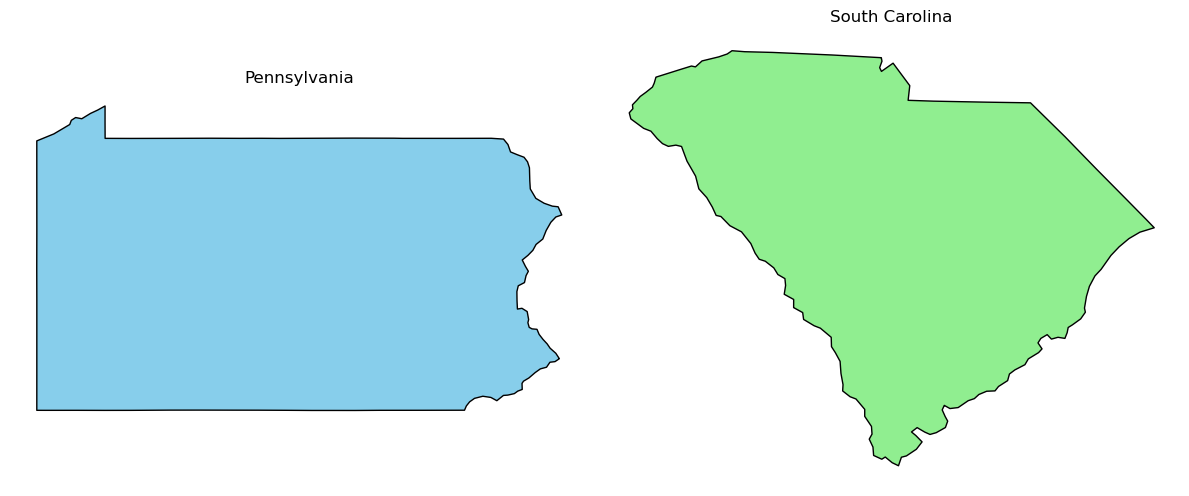

In [7]:

# ─────────────────────────────────────────────────────────────
# 5. Compare Two States
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pennsylvania
states[states["NAME"] == "Pennsylvania"].plot(ax=axes[0], color="skyblue", edgecolor="black")
axes[0].set_title("Pennsylvania")
axes[0].set_axis_off()

# South Carolina
states[states["NAME"] == "South Carolina"].plot(ax=axes[1], color="lightgreen", edgecolor="black")
axes[1].set_title("South Carolina")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

